In [ ]:
!wget https://raw.githubusercontent.com/gchoi/Dataset/master/UniversalBank.csv

--2021-12-25 03:24:26--  https://raw.githubusercontent.com/gchoi/Dataset/master/UniversalBank.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 205666 (201K) [text/plain]
Saving to: ‘UniversalBank.csv’

UniversalBank.csv   100%[===================>] 200.85K  --.-KB/s    in 0.01s   

2021-12-25 03:24:26 (18.5 MB/s) - ‘UniversalBank.csv’ saved [205666/205666]



In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# **1. Import Data**

In [ ]:
path_data = './UniversalBank.csv'
data_frame_original = pd.read_csv(path_data)
data_frame = data_frame_original.drop(['ID'], axis=1)
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                5000 non-null   int64  
 1   Experience         5000 non-null   int64  
 2   Income             5000 non-null   int64  
 3   ZIP Code           5000 non-null   int64  
 4   Family             5000 non-null   int64  
 5   CCAvg              5000 non-null   float64
 6   Education          5000 non-null   int64  
 7   Mortgage           5000 non-null   int64  
 8   PersonalLoan       5000 non-null   int64  
 9   SecuritiesAccount  5000 non-null   int64  
 10  CDAccount          5000 non-null   int64  
 11  Online             5000 non-null   int64  
 12  CreditCard         5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


In [ ]:
def stat_class(X, y, name_dataset):
    print('\n{} -> X Shape = {}'.format(name_dataset, X.shape, y.shape))
    print('Num category = {}, % category = {}'.format(np.bincount(y), np.bincount(y)/len(y)*100))


ind = [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12]
key_label = 'PersonalLoan'
X, y = data_frame.iloc[:, ind].values, data_frame[key_label].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

stat_class(X, y, 'ORIGINAL')
stat_class(X_train, y_train, 'TRAIN')
stat_class(X_test, y_test, 'TEST')


ORIGINAL -> X Shape = (5000, 12)
Num category = [4520  480], % category = [90.4  9.6]

TRAIN -> X Shape = (4000, 12)
Num category = [3605  395], % category = [90.125  9.875]

TEST -> X Shape = (1000, 12)
Num category = [915  85], % category = [91.5  8.5]


# **2. Visualize Data**

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


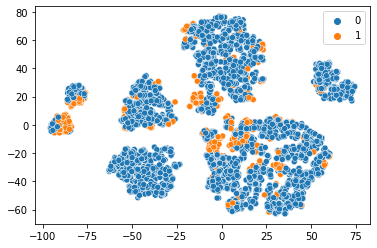

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2)
x_emb = tsne.fit_transform(X_train)
sns.scatterplot(x_emb[:, 0], x_emb[:, 1], hue=y_train)

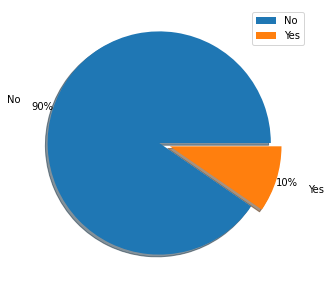

In [ ]:
list_pie = list(data_frame_original[key_label].value_counts())
temp_list = []

labels = ["No","Yes"]
for pie in list_pie:
  temp_list.append((pie/data_frame.shape[0])*100)
myexplode = [0.1, 0]
sizes = temp_list

fig = plt.figure(figsize =(5, 7)) 
plt.pie(sizes, labels = labels,explode = myexplode, shadow = True,autopct='%1.0f%%', pctdistance=1.1, labeldistance=1.3)
plt.legend()
plt.show()

# **3.1 Imbalance Data**

In [ ]:
def experiment_classifier(X_train, y_train, X_test, y_test):
    logs = []
    clfs = [SVC(), LogisticRegression(), GaussianNB(), DecisionTreeClassifier()]

    for clf in tqdm(clfs):
        model = clf
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc, rec, prec, f1 = accuracy_score(y_test, y_pred), recall_score(y_test, y_pred, average='macro'), precision_score(y_test, y_pred, average='macro'), f1_score(y_test, y_pred, average='macro')
        logs.append([str(clf), acc, prec, rec, f1])
    # name_clf, accuracy, preision, recall, f1-score
    return logs

# stat
stat_class(X_train, y_train, 'TRAIN imbalance + without PCA')

# Imbalance Data
imb_wo_pca_logs = experiment_classifier(X_train, y_train, X_test, y_test)
data_frame_311 = pd.DataFrame(imb_wo_pca_logs, columns=['Name Algo', 'Acc', 'Precision', 'Recall', 'F1-score'])
print('\n', data_frame_311.sort_values('F1-score', ascending=False))


TRAIN imbalance + without PCA -> X Shape = (4000, 12)
Num category = [3605  395], % category = [90.125  9.875]


100%|██████████| 4/4 [00:00<00:00, 18.75it/s]


                   Name Algo    Acc  Precision    Recall  F1-score
3  DecisionTreeClassifier()  0.988   0.961427  0.961427  0.961427
0                     SVC()  0.979   0.968894  0.892478  0.926567
1      LogisticRegression()  0.962   0.897475  0.845837  0.869432
2              GaussianNB()  0.884   0.678885  0.781871  0.712883


100%|██████████| 12/12 [00:00<00:00, 19.13it/s]


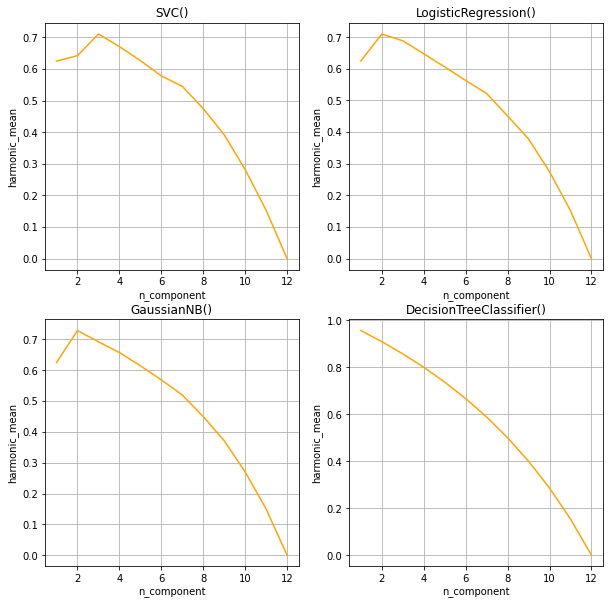


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876

                   Name Algo    Acc  Precision    Recall  F1-score
0                     SVC()  0.926   0.805686  0.618065  0.661395
2              GaussianNB()  0.895   0.653366  0.638476  0.645365
1      LogisticRegression()  0.904   0.661832  0.600707  0.621308
3  DecisionTreeClassifier()  0.847   0.537728  0.542880  0.539865


In [ ]:
def choosing_k(clf, X, y, i, visual=True):
  # chooes k for each classifier
  K = [i+1 for i in range(X.shape[1])]
  choose_k, best_harmonic_mean, beta = 0, 0, 1
  harmonic_means, scores_pca, scores_clf = [], [], []

  for k in tqdm(K):
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train)

    model = clf
    model.fit(X_train_pca, y_train)
    y_train_pred = model.predict(X_train_pca)

    score_clf = f1_score(y_train, y_train_pred, average='macro')
    score_pca = (1 - k/len(K))
    # beta < 1 -> score_pca is more importane, and else
    harmonic_mean = (1+beta**2) * score_clf * score_pca / ((beta**2)*score_clf + score_pca)
    
    harmonic_means.append(harmonic_mean)
    scores_pca.append(score_pca)
    scores_clf.append(score_clf)

    if harmonic_mean > best_harmonic_mean:
      choose_k = k
      best_harmonic_mean = harmonic_mean

  if visual==True:
    # Vsiualize k and harmonic
    plt.subplot(2, 2, i+1)
    plt.plot(K, harmonic_means, color='orange')
    #plt.plot(K, scores_pca, color='blue')
    #plt.plot(K, scores_clf, color='green')
    plt.xlabel('n_component')
    plt.ylabel('harmonic_mean')
    plt.title(str(clf))
    plt.grid()
  
  # Result choose k
  return [str(clf), choose_k, best_harmonic_mean]

    

def experiment_pca_and_classifier(X_train, y_train, X_test, y_test, visual=True):
  logs, logs_s = [], []
  clfs = [SVC(), LogisticRegression(), GaussianNB(), DecisionTreeClassifier()]
  plt.subplots(2,2,figsize=(10,10))

  for i, clf in enumerate(clfs):
    log_s = choosing_k(clf, X_train, y_train, i, visual)
    logs_s.append(log_s)
    choose_k = log_s[1]

    #best_pca = PCA(0.99)
    best_pca = PCA(choose_k)
    X_train_pca = best_pca.fit_transform(X_train)
    #stat_class(X_train_pca, y_train, '')
    
    best_clf = clf
    best_clf.fit(X_train_pca, y_train)

    X_test_pca = best_pca.transform(X_test)
    y_pred = best_clf.predict(X_test_pca)

    acc, rec, prec, f1 = accuracy_score(y_test, y_pred), recall_score(y_test, y_pred, average='macro'), precision_score(y_test, y_pred, average='macro'), f1_score(y_test, y_pred, average='macro')
    logs.append([str(clf), acc, prec, rec, f1])
  
  plt.show()
  return logs_s, logs


# Imbalance Data + PCA
imb_w_pca_logs_s, imb_w_pca_logs = experiment_pca_and_classifier(X_train, y_train, X_test, y_test)
data_frame_312s = pd.DataFrame(imb_w_pca_logs_s, columns=['Name Algo', 'n_component', 'harmonic_mean'])
data_frame_312 = pd.DataFrame(imb_w_pca_logs, columns=['Name Algo', 'Acc', 'Precision', 'Recall', 'F1-score'])
print('\n', data_frame_312s.sort_values('harmonic_mean', ascending=False))
print('\n', data_frame_312.sort_values('F1-score', ascending=False))

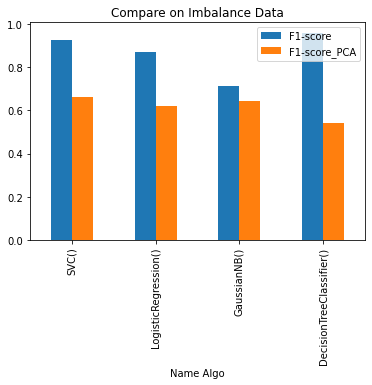

In [ ]:
def compare(non_pca, pca, key_join, title):
  pca.columns = ['Name Algo', 'Acc_PCA', 'Precision_PCA', 'Recall_PCA', 'F1-score_PCA']
  new_data_frame = non_pca.merge(pca, left_on=key_join, right_on=key_join)
  #new_data_frame.plot(x='Name Algo', y=['Acc', 'Acc'], kind='bar')
  new_data_frame.plot(x='Name Algo', y=['F1-score', 'F1-score_PCA'], kind='bar')
  #new_data_frame.plot(x='Name Algo', y=['Recall', 'Recall_PCA'], kind='bar')
  #new_data_frame.plot(x='Name Algo', y=['Precision', 'Precision_PCA'], kind='bar')
  plt.title(title)

compare(data_frame_311.copy(), data_frame_312.copy(), 'Name Algo', title='Compare on Imbalance Data')

# **3.2 Upsampling Data**

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_train_up, y_train_up = sm.fit_resample(X_train, y_train)
stat_class(X_train_up, y_train_up, 'TRAIN upsampling + without PCA')

up_wo_pca_logs = experiment_classifier(X_train_up, y_train_up, X_test, y_test)
data_frame_321 = pd.DataFrame(up_wo_pca_logs, columns=['Name Algo', 'Acc', 'Precision', 'Recall', 'F1-score'])
print('\n', data_frame_321.sort_values('F1-score', ascending=False))


TRAIN upsampling + without PCA -> X Shape = (7210, 12)
Num category = [3605 3605], % category = [50. 50.]


100%|██████████| 4/4 [00:00<00:00,  7.11it/s]


                   Name Algo    Acc  Precision    Recall  F1-score
3  DecisionTreeClassifier()  0.982   0.930766  0.958149  0.943929
0                     SVC()  0.972   0.885562  0.958020  0.917806
1      LogisticRegression()  0.893   0.715786  0.909515  0.767277
2              GaussianNB()  0.878   0.690959  0.863967  0.735498


100%|██████████| 12/12 [00:00<00:00, 17.29it/s]


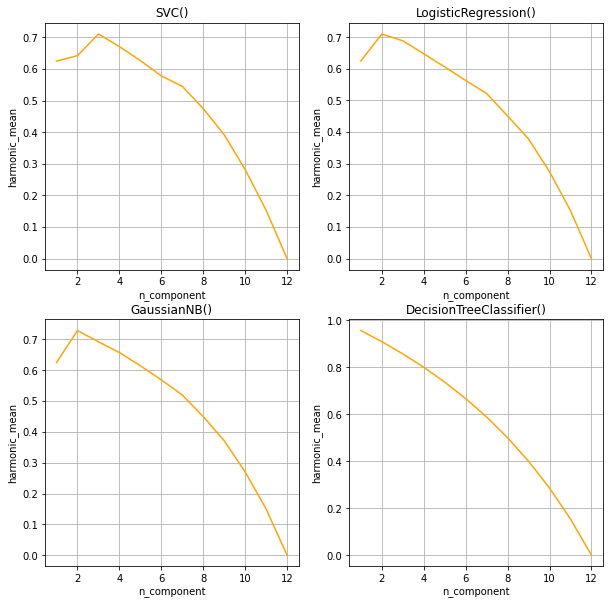


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876

                   Name Algo    Acc  Precision    Recall  F1-score
2              GaussianNB()  0.865   0.662833  0.798168  0.698628
1      LogisticRegression()  0.837   0.652389  0.836226  0.684704
0                     SVC()  0.803   0.643625  0.865670  0.664138
3  DecisionTreeClassifier()  0.745   0.595661  0.759274  0.591497


In [ ]:
up_w_pca_logs_s, up_w_pca_logs = experiment_pca_and_classifier(X_train_up, y_train_up, X_test, y_test)
data_frame_322s = pd.DataFrame(up_w_pca_logs_s, columns=['Name Algo', 'n_component', 'harmonic_mean'])
data_frame_322 = pd.DataFrame(up_w_pca_logs, columns=['Name Algo', 'Acc', 'Precision', 'Recall', 'F1-score'])
print('\n', data_frame_322s.sort_values('harmonic_mean', ascending=False))
print('\n', data_frame_322.sort_values('F1-score', ascending=False))

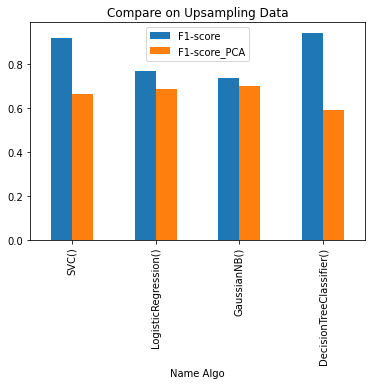

In [ ]:
compare(data_frame_321.copy(), data_frame_322.copy(), 'Name Algo', title='Compare on Upsampling Data')

# **3.3 DownSampling Data**

In [ ]:
data_frame_train_copy = pd.DataFrame(X_train, columns=data_frame_original.keys().drop(['ID', 'PersonalLoan']))
data_frame_train_copy[key_label] = y_train

df_per_0 = data_frame_train_copy[data_frame_train_copy[key_label] == 0]
df_per_1 = data_frame_train_copy[data_frame_train_copy[key_label] == 1]


df_concat_1 = pd.concat([df_per_0,df_per_1])
df_per_0.shape, df_per_1.shape, df_concat_1

((3605, 13),
 (395, 13),
            Age  Experience    Income  ...    Online  CreditCard  PersonalLoan
 0     1.284601    1.215332 -0.206895  ... -1.224745   -0.647647             0
 1     0.233982    0.166049 -1.294617  ...  0.816497   -0.647647             0
 2    -1.341948   -1.232995 -0.685493  ... -1.224745    1.544051             0
 4     0.759292    0.690691  0.119421  ... -1.224745   -0.647647             0
 5     0.409085    0.428370  1.228896  ... -1.224745   -0.647647             0
 ...        ...         ...       ...  ...       ...         ...           ...
 3964 -1.341948   -1.232995  2.555916  ...  0.816497   -0.647647             1
 3975 -1.429499   -1.495316  2.207845  ...  0.816497   -0.647647             1
 3983 -1.341948   -1.407876  1.489949  ... -1.224745   -0.647647             1
 3992 -1.166844   -1.058114  2.077319  ...  0.816497   -0.647647             1
 3996  0.146430    0.166049  0.467492  ... -1.224745   -0.647647             1
 
 [4000 rows x 13 columns]

In [ ]:
df_list = []
df_per_0 = df_per_0.sample(frac = 1)

for i in range(df_per_0.shape[0]//df_per_1.shape[0]):
  loc_increment =  i * df_per_1.shape[0]
  df_0 = df_per_0.iloc[loc_increment:loc_increment + df_per_1.shape[0]]
  df_1 = df_per_1
  df_concat_2 = pd.concat([df_0,df_1])
  print("Fold number {}:".format(i+1),df_concat_2.shape)
  print(df_concat_2.describe())
  df_list.append(df_concat_2)


Fold number 1: (790, 13)
              Age  Experience      Income  ...      Online  CreditCard  PersonalLoan
count  790.000000  790.000000  790.000000  ...  790.000000  790.000000    790.000000
mean     0.009340    0.012973    0.647613  ...    0.038758   -0.026203      0.500000
std      1.004055    1.005951    1.177118  ...    0.991928    0.988464      0.500317
min     -1.867257   -1.845077   -1.425143  ...   -1.224745   -0.647647      0.000000
25%     -0.904189   -0.883234   -0.440755  ...   -1.224745   -0.647647      0.000000
50%      0.015103   -0.008831    0.685036  ...    0.816497   -0.647647      0.500000
75%      0.846843    0.865571    1.642230  ...    0.816497    1.544051      1.000000
max      1.809911    1.827414    3.143285  ...    0.816497    1.544051      1.000000

[8 rows x 13 columns]
Fold number 2: (790, 13)
              Age  Experience      Income  ...      Online  CreditCard  PersonalLoan
count  790.000000  790.000000  790.000000  ...  790.000000  790.000000    790

In [ ]:
def experiment_classifier_k_fold(df_list, pca = False):
  print('Fold 0 is being processed')
  X_train_down, y_train_down = df_list[0].iloc[:, :-1].values, df_list[0].iloc[:, -1].values
  if pca == True:
    logs_s, logs = experiment_pca_and_classifier(X_train_down, y_train_down, X_test, y_test, visual=True)
    logs_s = pd.DataFrame(logs_s, columns=['Name Algo', 'n_component', 'harmonic_mean'])
    print('\n', logs_s.sort_values('harmonic_mean', ascending=False))
  else:
    logs = experiment_classifier(X_train_down, y_train_down, X_test, y_test)
  data_frame_one = pd.DataFrame(logs, columns=['Name Algo', 'Acc', 'Precision', 'Recall', 'F1-score'])
  #print('\n\n', data_frame_one.sort_values('F1-score', ascending=False))
  
  for fold in range(1,len(df_list)):
    print('\nFold {} is being processed'.format(fold))
    X_train_down, y_train_down = df_list[fold].iloc[:, :-1].values, df_list[fold].iloc[:, -1].values
    if pca == True:
      logs_s, logs = experiment_pca_and_classifier(X_train_down, y_train_down, X_test, y_test, visual=True)
      logs_s = pd.DataFrame(logs_s, columns=['Name Algo', 'n_component', 'harmonic_mean'])
      print('\n', logs_s.sort_values('harmonic_mean', ascending=False))
    else:
      logs = experiment_classifier(X_train_down, y_train_down, X_test, y_test)
    
    data_frame_one_t = pd.DataFrame(logs, columns=['Name Algo', 'Acc', 'Precision', 'Recall', 'F1-score'])
    data_frame_one.iloc[:, 1:] = (data_frame_one.iloc[:, 1:] + data_frame_one_t.iloc[:, 1:])/2
  print('\n\n', data_frame_one.sort_values('F1-score', ascending=False))
  return data_frame_one

# Fold number 1
X_train_down, y_train_down = df_list[0].iloc[:, :-1].values, df_list[0].iloc[:, -1].values
stat_class(X_train_down, y_train_down, 'TRAIN downsampling + without PCA')
data_frame_331 = experiment_classifier_k_fold(df_list)


TRAIN downsampling + without PCA -> X Shape = (790, 12)
Num category = [395 395], % category = [50. 50.]
Fold 0 is being processed


100%|██████████| 4/4 [00:00<00:00, 65.75it/s]



Fold 1 is being processed


100%|██████████| 4/4 [00:00<00:00, 54.45it/s]



Fold 2 is being processed


...


Fold 7 is being processed


100%|██████████| 4/4 [00:00<00:00, 52.31it/s]



Fold 8 is being processed


100%|██████████| 4/4 [00:00<00:00, 51.54it/s]



                   Name Algo       Acc  Precision    Recall  F1-score
3  DecisionTreeClassifier()  0.952492   0.822442  0.961492  0.875186
0                     SVC()  0.925656   0.765700  0.940783  0.822443
1      LogisticRegression()  0.882555   0.704861  0.909622  0.754392
2              GaussianNB()  0.879859   0.692494  0.862127  0.737074


Fold 0 is being processed


100%|██████████| 12/12 [00:00<00:00, 15.99it/s]


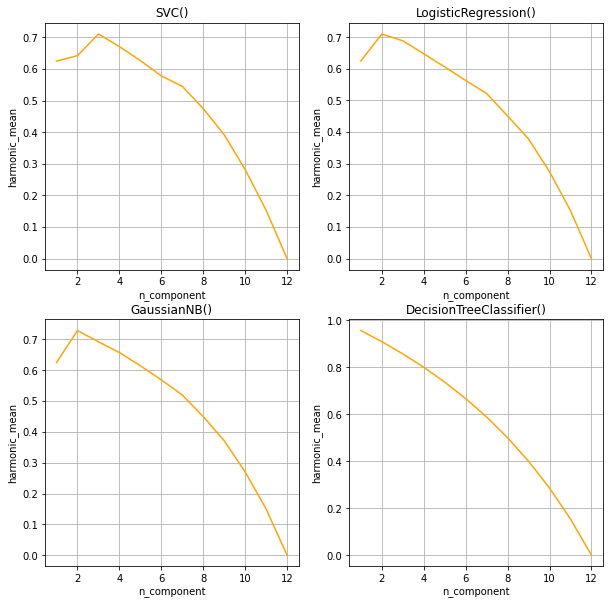


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876

Fold 1 is being processed


100%|██████████| 12/12 [00:00<00:00, 19.51it/s]


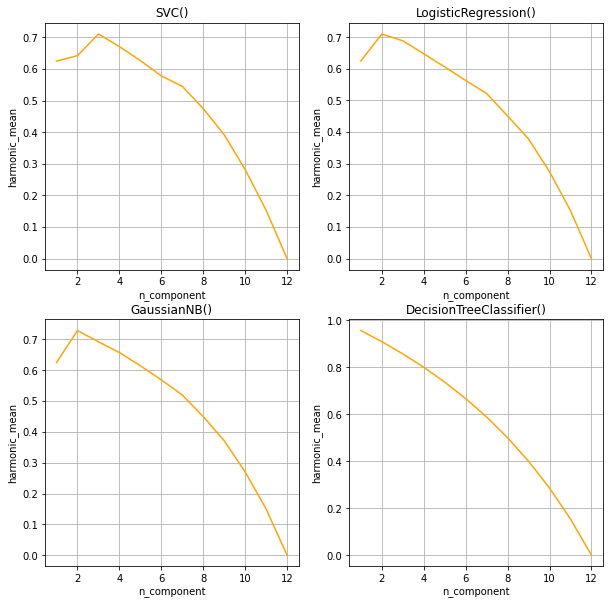


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876

Fold 2 is being processed


100%|██████████| 12/12 [00:00<00:00, 18.50it/s]


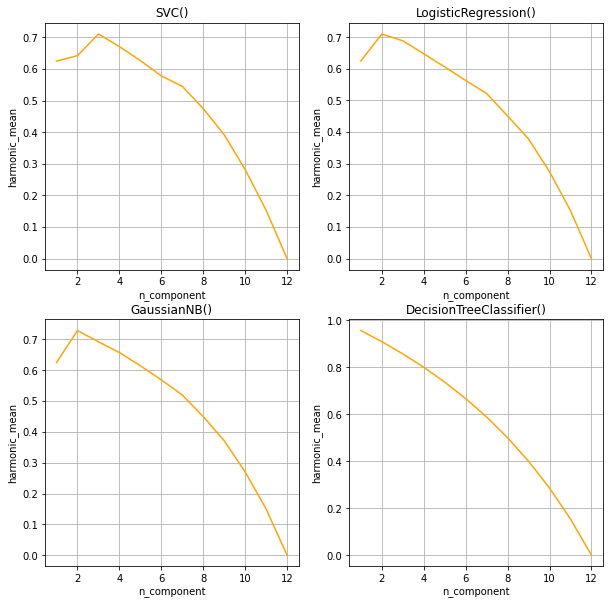


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876

Fold 3 is being processed


100%|██████████| 12/12 [00:00<00:00, 20.73it/s]


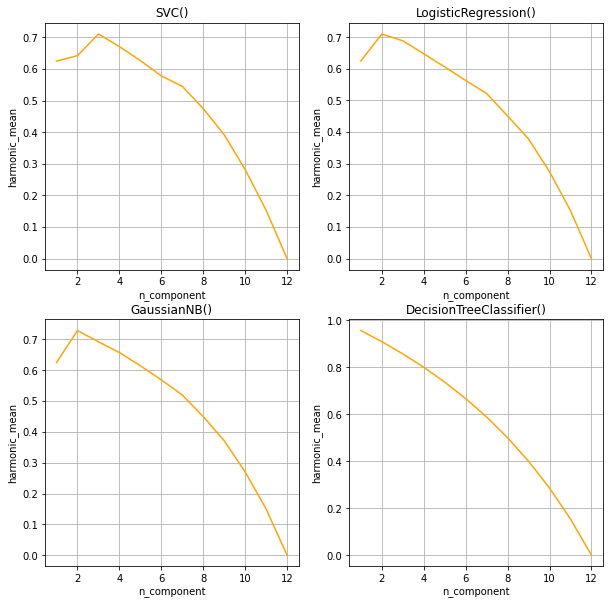


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876

Fold 4 is being processed


100%|██████████| 12/12 [00:00<00:00, 16.26it/s]


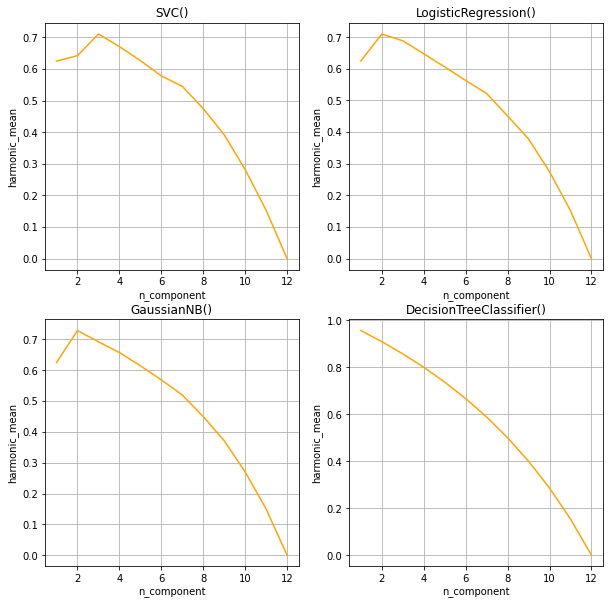


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876

Fold 5 is being processed


100%|██████████| 12/12 [00:00<00:00, 15.19it/s]


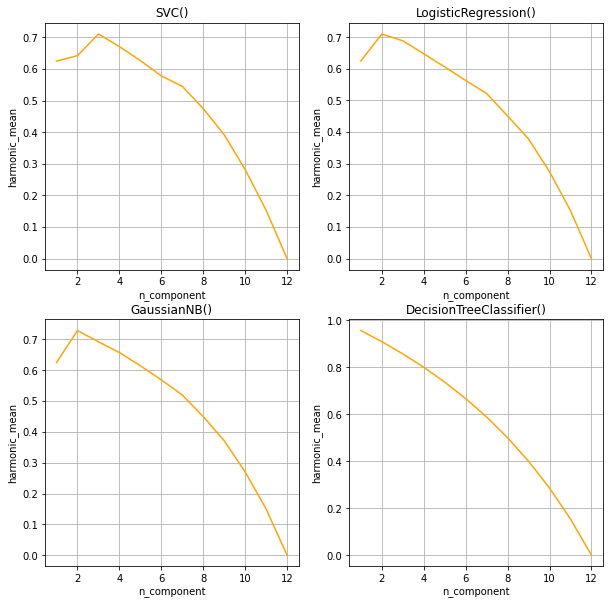


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876

Fold 6 is being processed


100%|██████████| 12/12 [00:00<00:00, 20.31it/s]


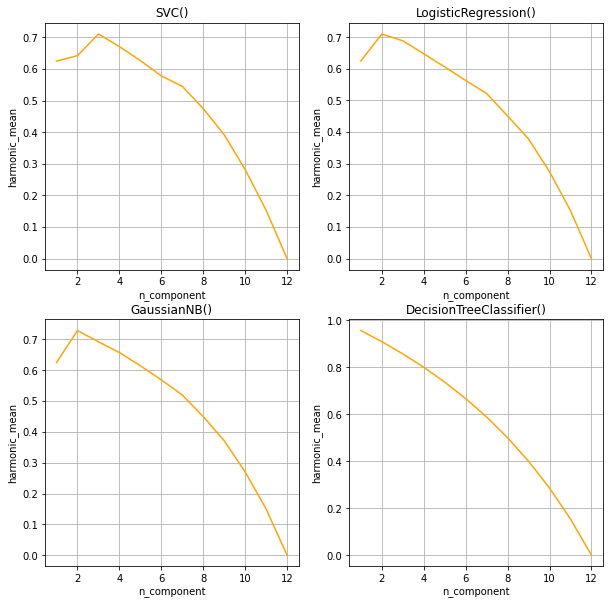


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876

Fold 7 is being processed


100%|██████████| 12/12 [00:00<00:00, 17.35it/s]


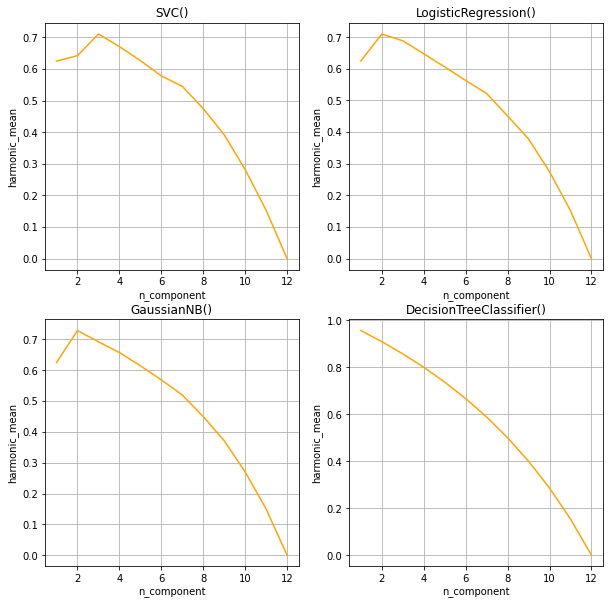


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876

Fold 8 is being processed


100%|██████████| 12/12 [00:00<00:00, 16.48it/s]


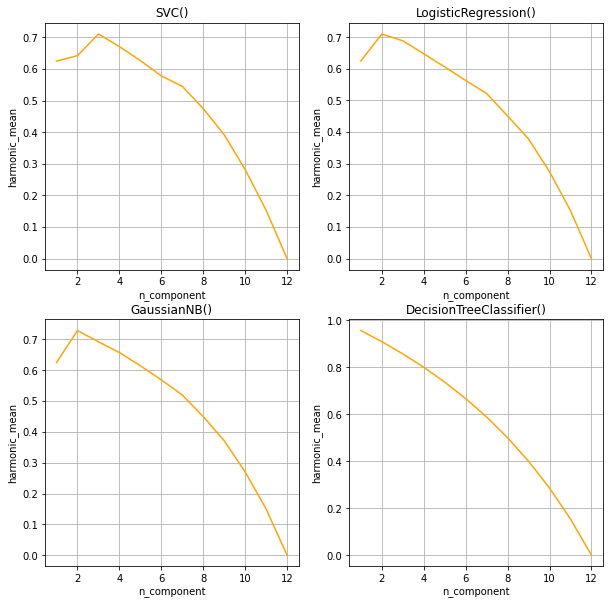


                   Name Algo  n_component  harmonic_mean
3  DecisionTreeClassifier()            1       0.956522
2              GaussianNB()            2       0.728703
0                     SVC()            3       0.710445
1      LogisticRegression()            2       0.709876


                   Name Algo       Acc  Precision    Recall  F1-score
2              GaussianNB()  0.866805   0.658638  0.776747  0.691991
1      LogisticRegression()  0.835430   0.648073  0.823279  0.679192
0                     SVC()  0.798184   0.638350  0.852804  0.656728
3  DecisionTreeClassifier()  0.723184   0.591351  0.758149  0.577704


In [ ]:
data_frame_332 = experiment_classifier_k_fold(df_list, pca=True)

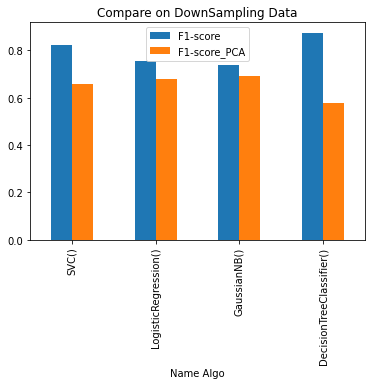

In [ ]:
compare(data_frame_331.copy(), data_frame_332.copy(), 'Name Algo', title='Compare on DownSampling Data')